# 01 Data Exploration

Purpose: understand the PCOS dataset before preprocessing or modelling.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA = PROJECT_ROOT / "data" / "raw" / "PCOS_Data.csv"
EDA_DIR = PROJECT_ROOT / "outputs" / "eda_figures"
EDA_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Dataset

In [2]:
df = pd.read_csv(RAW_DATA)
df.columns = df.columns.str.strip()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (541, 44)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


## 3. Basic Information

In [3]:
print("Shape:", df.shape)
display(df.head())
display(df.tail())
display(df.info())
display(df.describe(include="all").T)

Shape: (541, 44)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
536,537,537,0,35,50.0,164.592,18.5,17,72,16,...,0,0.0,0,110,70,1,0,17.5,10.0,6.7
537,538,538,0,30,63.2,158.000,25.3,15,72,18,...,0,0.0,0,110,70,9,7,19.0,18.0,8.2
538,539,539,0,36,54.0,152.000,23.4,13,74,20,...,0,0.0,0,110,80,1,0,18.0,9.0,7.3
539,540,540,0,27,50.0,150.000,22.2,15,74,20,...,1,0.0,0,110,70,7,6,18.0,16.0,11.5
540,541,541,1,23,82.0,165.000,30.1,13,80,20,...,1,1.0,0,120,70,9,10,19.0,18.0,6.9


<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3   Age (yrs)               541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    int64  
 15  

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sl. No,541.0,NaN,NaN,NaN,271.0,156.317519,1.0,136.0,271.0,406.0,541.0
Patient File No.,541.0,NaN,NaN,NaN,271.0,156.317519,1.0,136.0,271.0,406.0,541.0
PCOS (Y/N),541.0,NaN,NaN,NaN,0.327172,0.469615,0.0,0.0,0.0,1.0,1.0
Age (yrs),541.0,NaN,NaN,NaN,31.430684,5.411006,20.0,28.0,31.0,35.0,48.0
Weight (Kg),541.0,NaN,NaN,NaN,59.637153,11.028287,31.0,52.0,59.0,65.0,108.0
Height(Cm),541.0,NaN,NaN,NaN,156.484835,6.033545,137.0,152.0,156.0,160.0,180.0
BMI,541.0,NaN,NaN,NaN,24.307579,4.055129,12.4,21.6,24.2,26.6,38.9
Blood Group,541.0,NaN,NaN,NaN,13.802218,1.840812,11.0,13.0,14.0,15.0,18.0
Pulse rate(bpm),541.0,NaN,NaN,NaN,73.247689,4.430285,13.0,72.0,72.0,74.0,82.0
RR (breaths/min),541.0,NaN,NaN,NaN,19.243993,1.688629,16.0,18.0,18.0,20.0,28.0


## 4. Data Types and Numeric Conversion Check

In [4]:
display(df.dtypes.to_frame("dtype"))

object_cols = df.select_dtypes(include="object").columns.tolist()
print("Object columns:", object_cols)
for col in object_cols:
    converted = pd.to_numeric(df[col], errors="coerce")
    print(f"{col}: non-numeric values after conversion = {converted.isna().sum() - df[col].isna().sum()}")

,dtype
Sl. No,int64
Patient File No.,int64
PCOS (Y/N),int64
Age (yrs),int64
Weight (Kg),float64
Height(Cm),float64
BMI,float64
Blood Group,int64
Pulse rate(bpm),int64
RR (breaths/min),int64


Object columns: ['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']
II    beta-HCG(mIU/mL): non-numeric values after conversion = 1
AMH(ng/mL): non-numeric values after conversion = 1


## 5. Missing Values

,Missing Count,Missing %
Fast food (Y/N),1,0.184843
Marraige Status (Yrs),1,0.184843


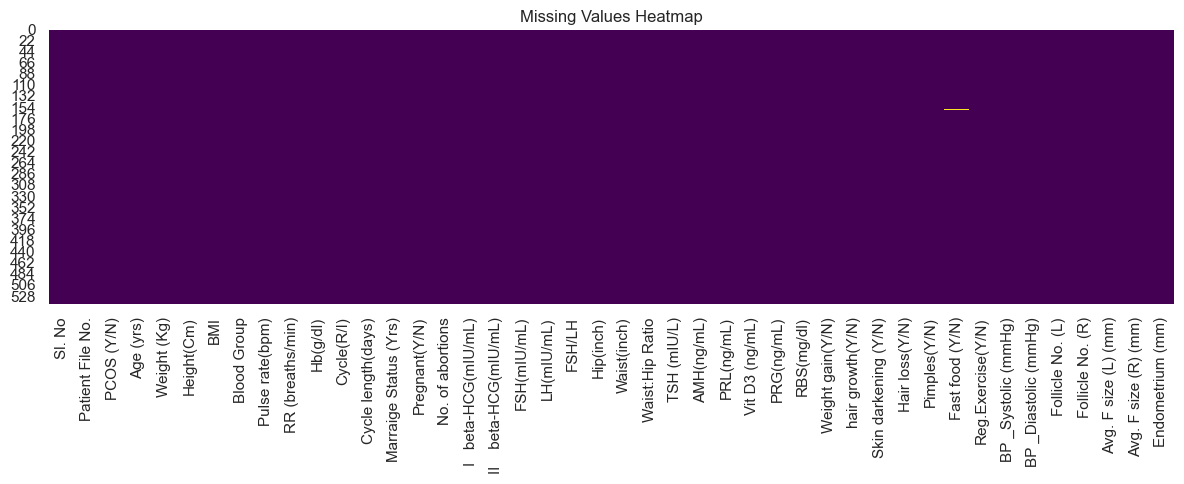

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent})
display(missing_table[missing_table["Missing Count"] > 0])

plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig(EDA_DIR / "missing_values_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Duplicate Values

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")
if duplicate_count:
    display(df[df.duplicated(keep=False)].head())

Duplicate rows: 0


## 7. Target Distribution

,Count
PCOS (Y/N),
No,364
Yes,177


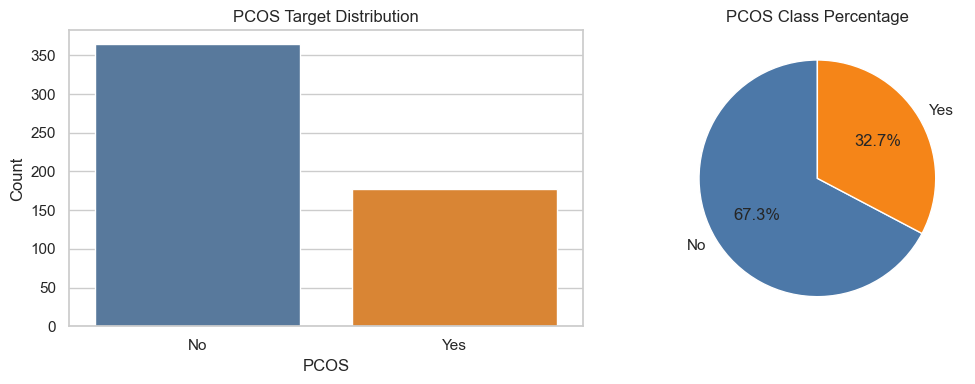

In [7]:
target_col = "PCOS (Y/N)"
target_counts = df[target_col].value_counts().rename(index={0: "No", 1: "Yes"})
display(target_counts.to_frame("Count"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=target_col, data=df, ax=axes[0], palette=["#4C78A8", "#F58518"])
axes[0].set_xticklabels(["No", "Yes"])
axes[0].set_title("PCOS Target Distribution")
axes[0].set_xlabel("PCOS")
axes[0].set_ylabel("Count")

axes[1].pie(target_counts, labels=target_counts.index, autopct="%1.1f%%", startangle=90, colors=["#4C78A8", "#F58518"])
axes[1].set_title("PCOS Class Percentage")
plt.tight_layout()
plt.savefig(EDA_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Numerical Distributions and Boxplots

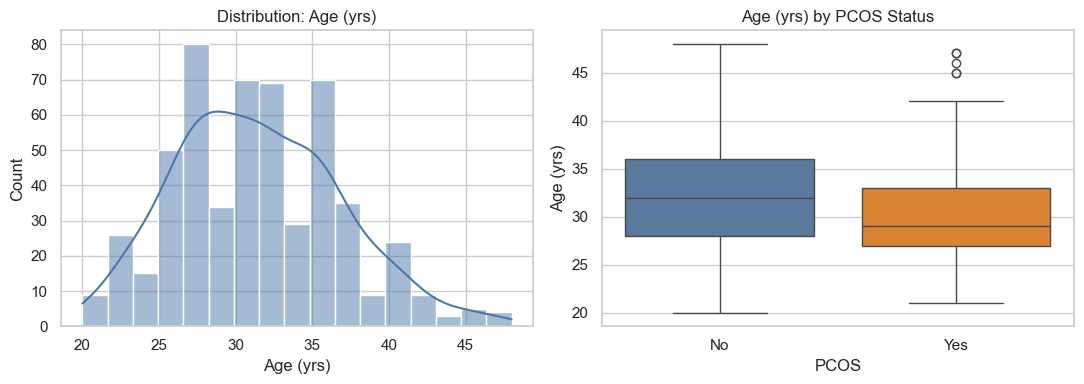

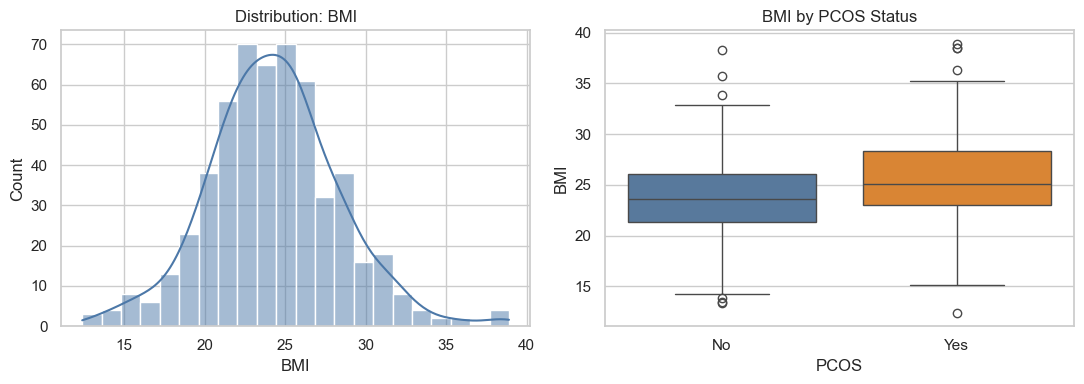

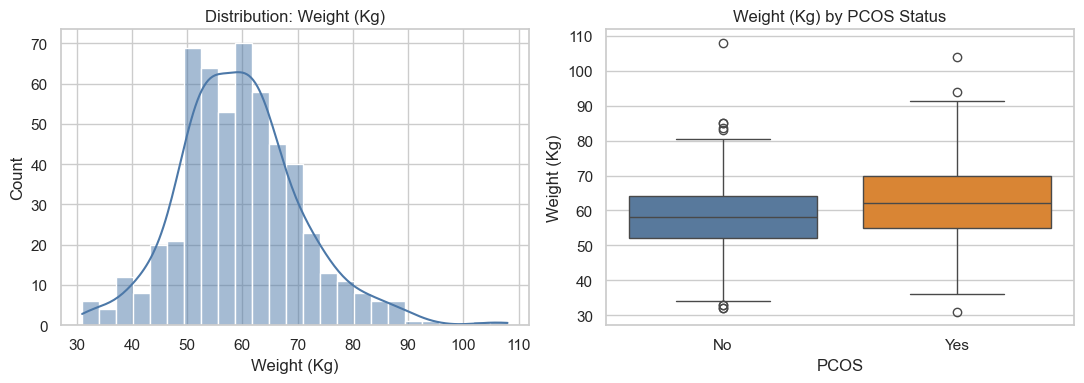

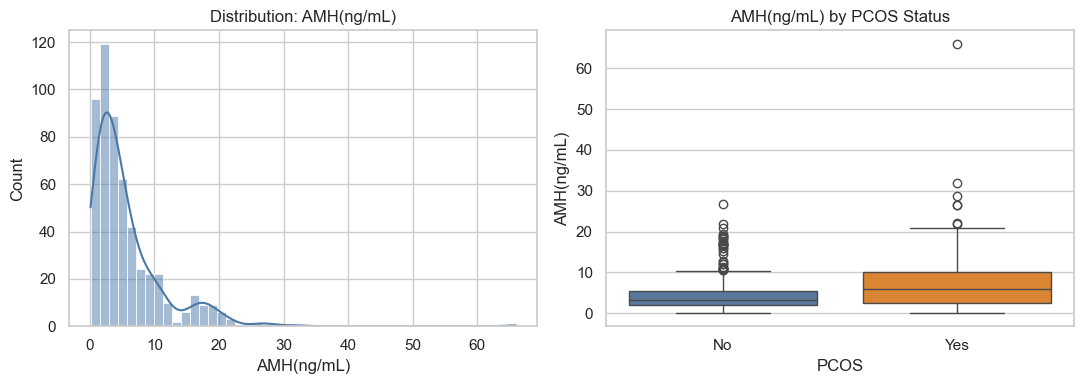

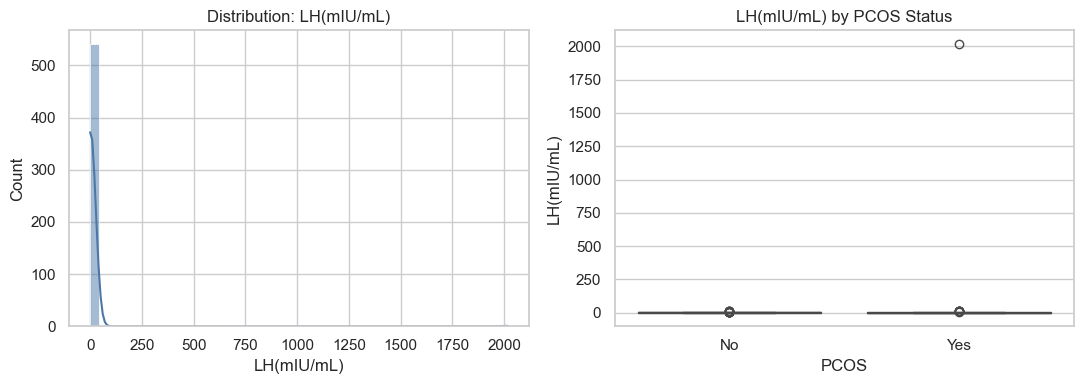

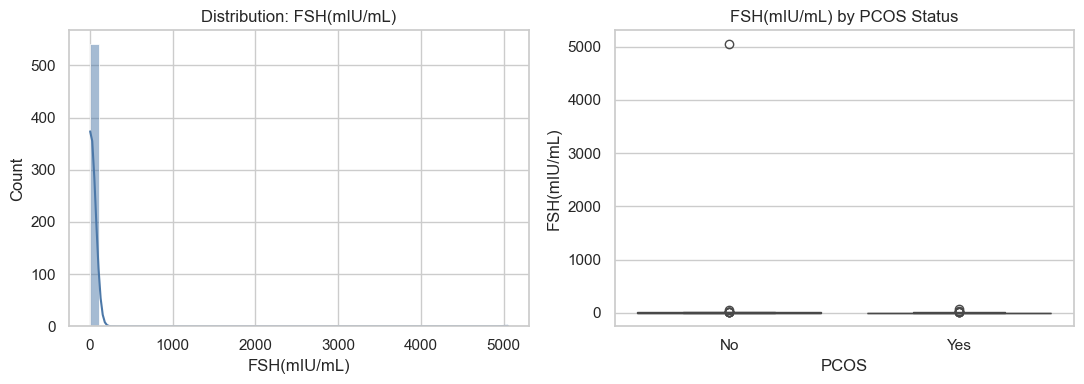

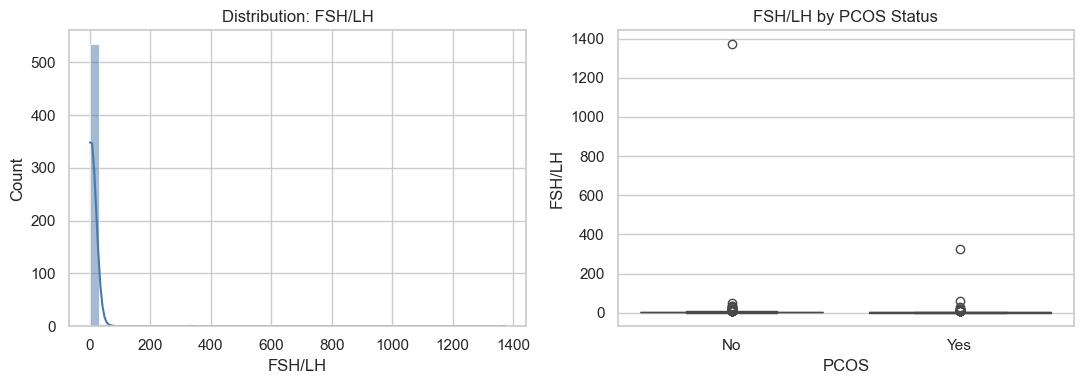

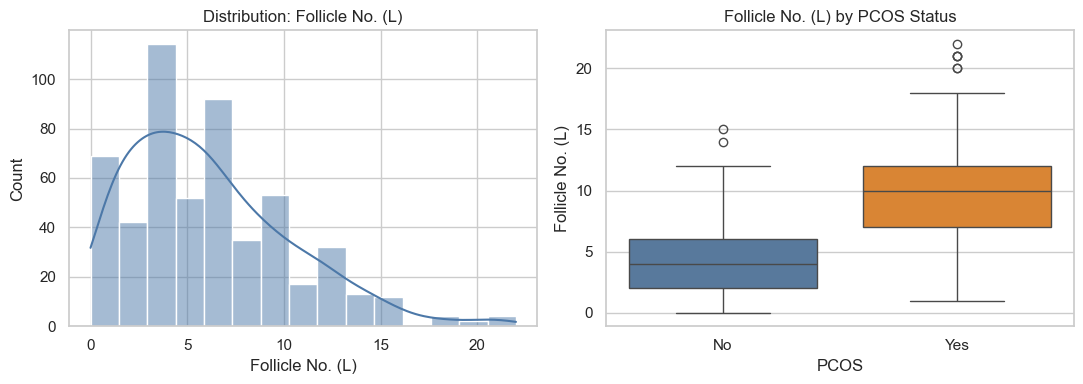

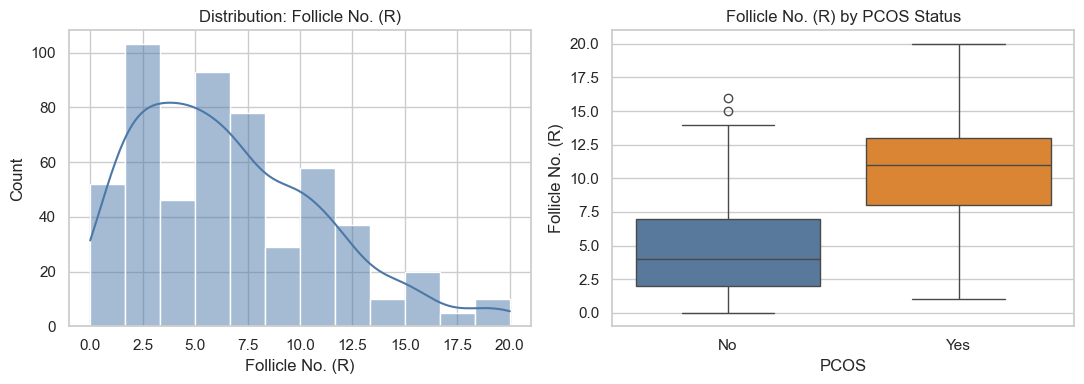

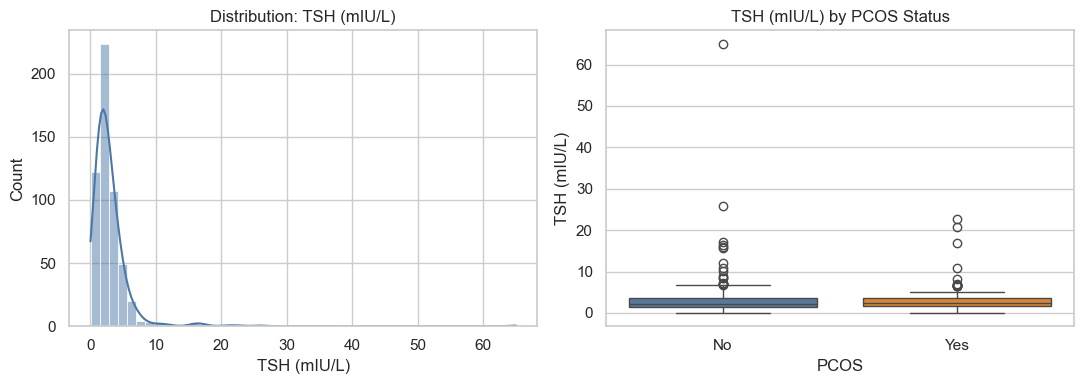

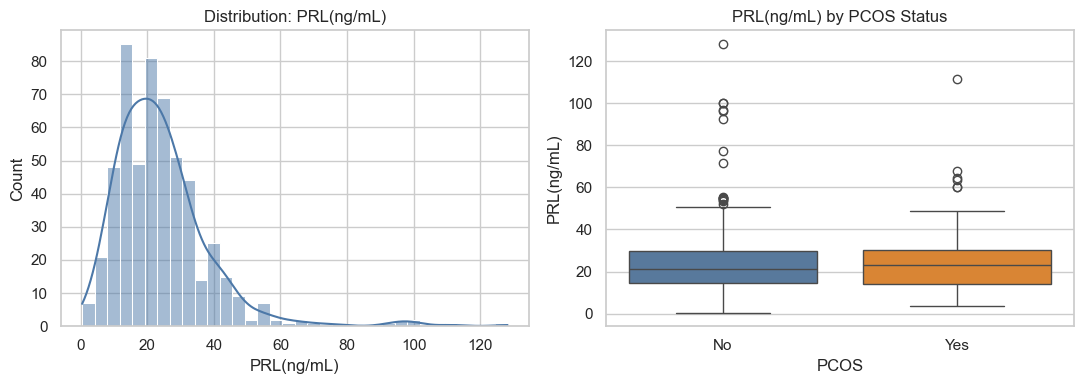

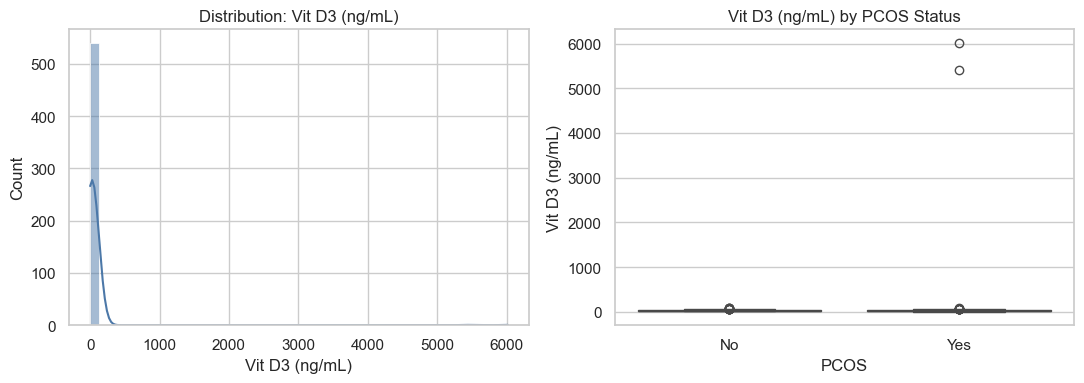

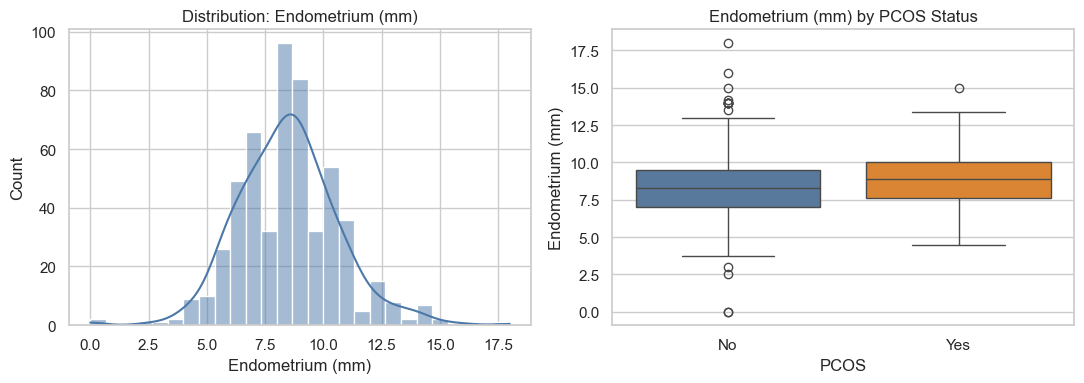

In [8]:
numeric_df = df.apply(pd.to_numeric, errors="coerce")
important_cols = [
    "Age (yrs)", "BMI", "Weight (Kg)", "AMH(ng/mL)", "LH(mIU/mL)", "FSH(mIU/mL)",
    "FSH/LH", "Follicle No. (L)", "Follicle No. (R)", "TSH (mIU/L)", "PRL(ng/mL)",
    "Vit D3 (ng/mL)", "Endometrium (mm)"
]
important_cols = [c for c in important_cols if c in numeric_df.columns]

for col in important_cols:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.histplot(numeric_df[col], kde=True, ax=axes[0], color="#4C78A8")
    axes[0].set_title(f"Distribution: {col}")
    sns.boxplot(x=df[target_col].map({0: "No", 1: "Yes"}), y=numeric_df[col], ax=axes[1], palette=["#4C78A8", "#F58518"])
    axes[1].set_title(f"{col} by PCOS Status")
    axes[1].set_xlabel("PCOS")
    plt.tight_layout()
    safe_name = col.replace("/", "_").replace(" ", "_").replace("(", "").replace(")", "").replace(":", "_")
    plt.savefig(EDA_DIR / f"{safe_name}_distribution_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

## 9. Correlation Heatmap and Important Predictors

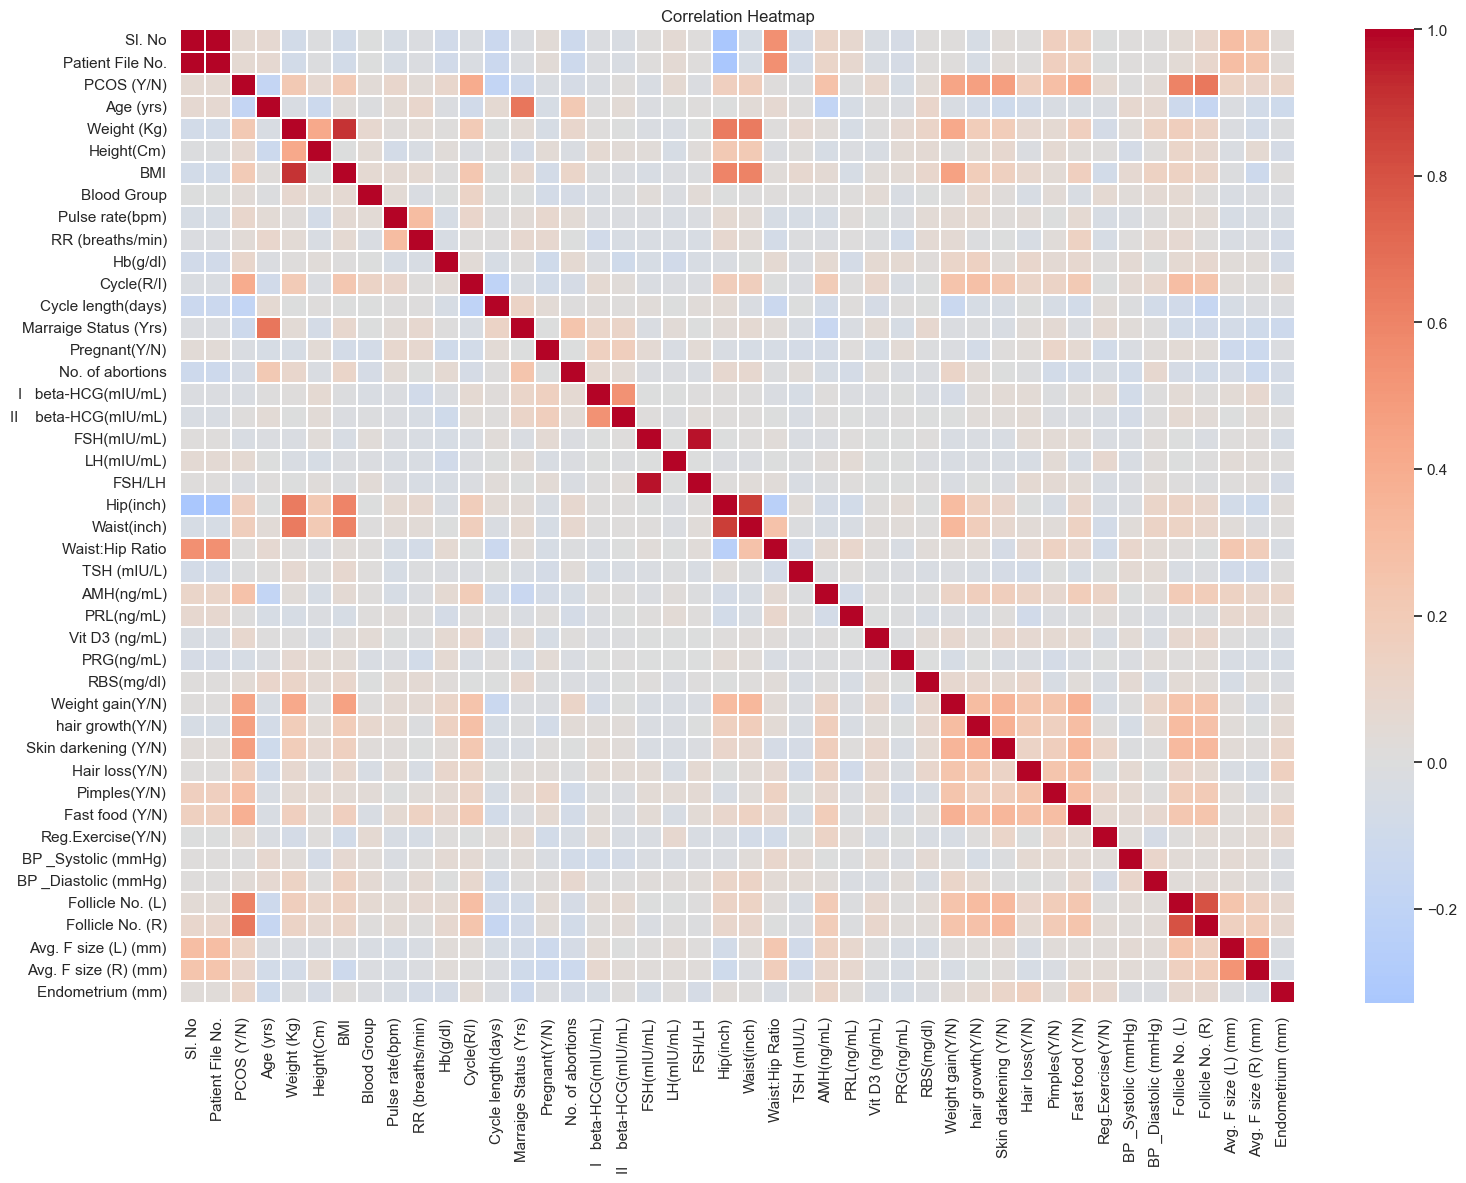

,Absolute correlation with PCOS
Follicle No. (R),0.648327
Follicle No. (L),0.603346
Skin darkening (Y/N),0.475733
hair growth(Y/N),0.464667
Weight gain(Y/N),0.441047
Cycle(R/I),0.401644
Fast food (Y/N),0.377933
Pimples(Y/N),0.286077
AMH(ng/mL),0.263863
Weight (Kg),0.211938


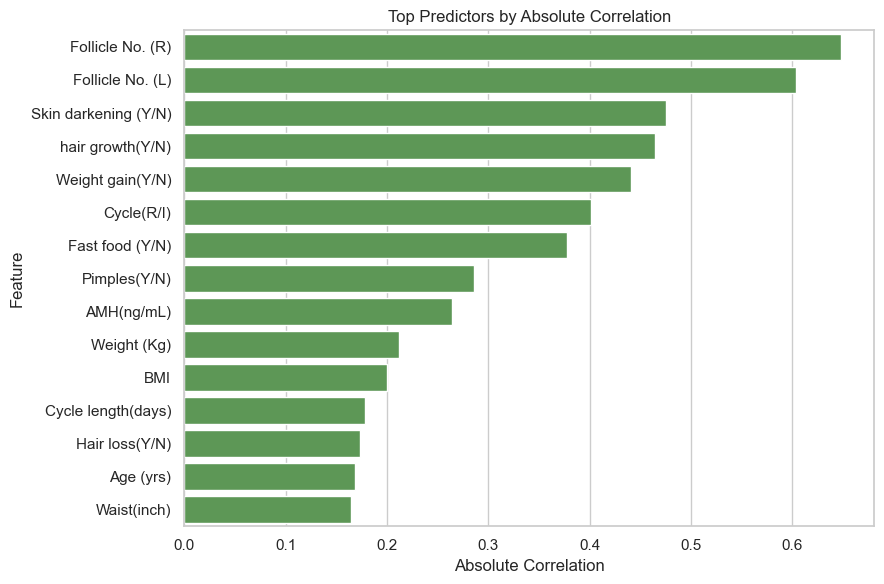

In [9]:
corr = numeric_df.corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(EDA_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
display(target_corr.head(15).to_frame("Absolute correlation with PCOS"))

plt.figure(figsize=(9, 6))
sns.barplot(x=target_corr.head(15).values, y=target_corr.head(15).index, color="#54A24B")
plt.title("Top Predictors by Absolute Correlation")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(EDA_DIR / "top_correlation_predictors.png", dpi=300, bbox_inches="tight")
plt.show()